# Ejemplos Metaheurísticas: Simulated Annealing y Algoritmos Genéticos

**Simulaciones y Procesos Estocásticos — UCA 2026**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation
from itertools import permutations

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. Función multimodal: el problema que motiva las metaheurísticas

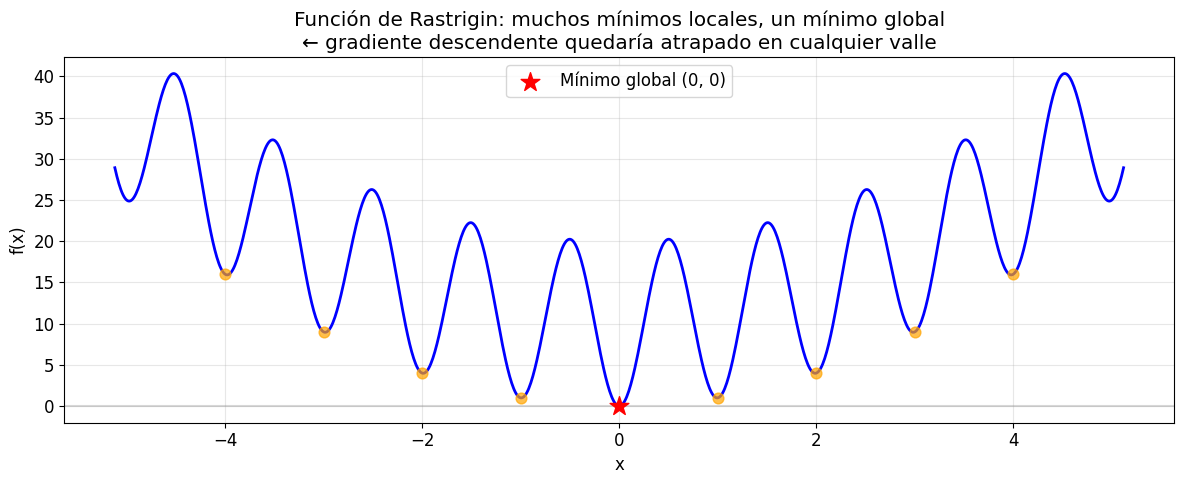

In [2]:
# Función de Rastrigin: clásica para benchmarking de metaheurísticas
# f(x) = An + sum[x_i^2 - A*cos(2*pi*x_i)]
# Mínimo global: f(0,...,0) = 0
def rastrigin_1d(x, A=10):
    return A + x**2 - A * np.cos(2 * np.pi * x)

x_grid = np.linspace(-5.12, 5.12, 1000)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_grid, rastrigin_1d(x_grid), 'b-', lw=2)
ax.scatter([0], [0], color='red', s=200, marker='*', zorder=5, label='Mínimo global (0, 0)')
# Mínimos locales aproximados
minimos_loc = [-4, -3, -2, -1, 1, 2, 3, 4]
for xl in minimos_loc:
    ax.scatter([xl], [rastrigin_1d(xl)], color='orange', s=60, zorder=4, alpha=0.7)
ax.axhline(0, color='gray', alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Función de Rastrigin: muchos mínimos locales, un mínimo global\n← gradiente descendente quedaría atrapado en cualquier valle')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Simulated Annealing (SA)

In [28]:
def simulated_annealing_1d(f, x0, T0, alpha_cool, sigma_propuesta, max_iter=5000):
    """
    Simulated Annealing en 1D.
    - f: función a minimizar
    - T0: temperatura inicial
    - alpha_cool: factor de enfriamiento (T <- alpha*T)
    - sigma_propuesta: std del movimiento propuesto
    """
    x = x0
    T = T0
    f_actual = f(x)
    
    mejor_x = x
    mejor_f = f_actual
    
    historia = {'x': [x], 'f': [f_actual], 'T': [T], 'aceptado': [True]}
    
    for i in range(max_iter):
        # Propuesta: movimiento gaussiano
        x_propuesto = x + np.random.normal(0, sigma_propuesta)
        f_propuesto = f(x_propuesto)
        
        delta_E = f_propuesto - f_actual
        
        # Criterio de aceptación de Metropolis
        if delta_E < 0:  # mejora: siempre aceptar
            aceptar = True
        else:  # empeora: aceptar con probabilidad exp(-dE/T)
            aceptar = np.random.random() < np.exp(-delta_E / T)
        
        if aceptar:
            x = x_propuesto
            f_actual = f_propuesto
            
            if f_actual < mejor_f:
                mejor_x = x
                mejor_f = f_actual
        
        # Enfriamiento
        T *= alpha_cool
        
        historia['x'].append(x)
        historia['f'].append(f_actual)
        historia['T'].append(T)
        historia['aceptado'].append(aceptar)
    
    return mejor_x, mejor_f, historia

# Ejecutar SA en Rastrigin
x0_sa = -4.5  # empezar lejos del mínimo global
mejor_x, mejor_f, hist_sa = simulated_annealing_1d(
    rastrigin_1d, x0=x0_sa, T0=10.0, alpha_cool=0.9995, 
    sigma_propuesta=0.3, max_iter=3000
)

print(f"SA encontró: x* = {mejor_x:.4f}, f* = {mejor_f:.4f}")
print(f"Mínimo global: x*=0, f*=0")

SA encontró: x* = 0.0020, f* = 0.0008
Mínimo global: x*=0, f*=0


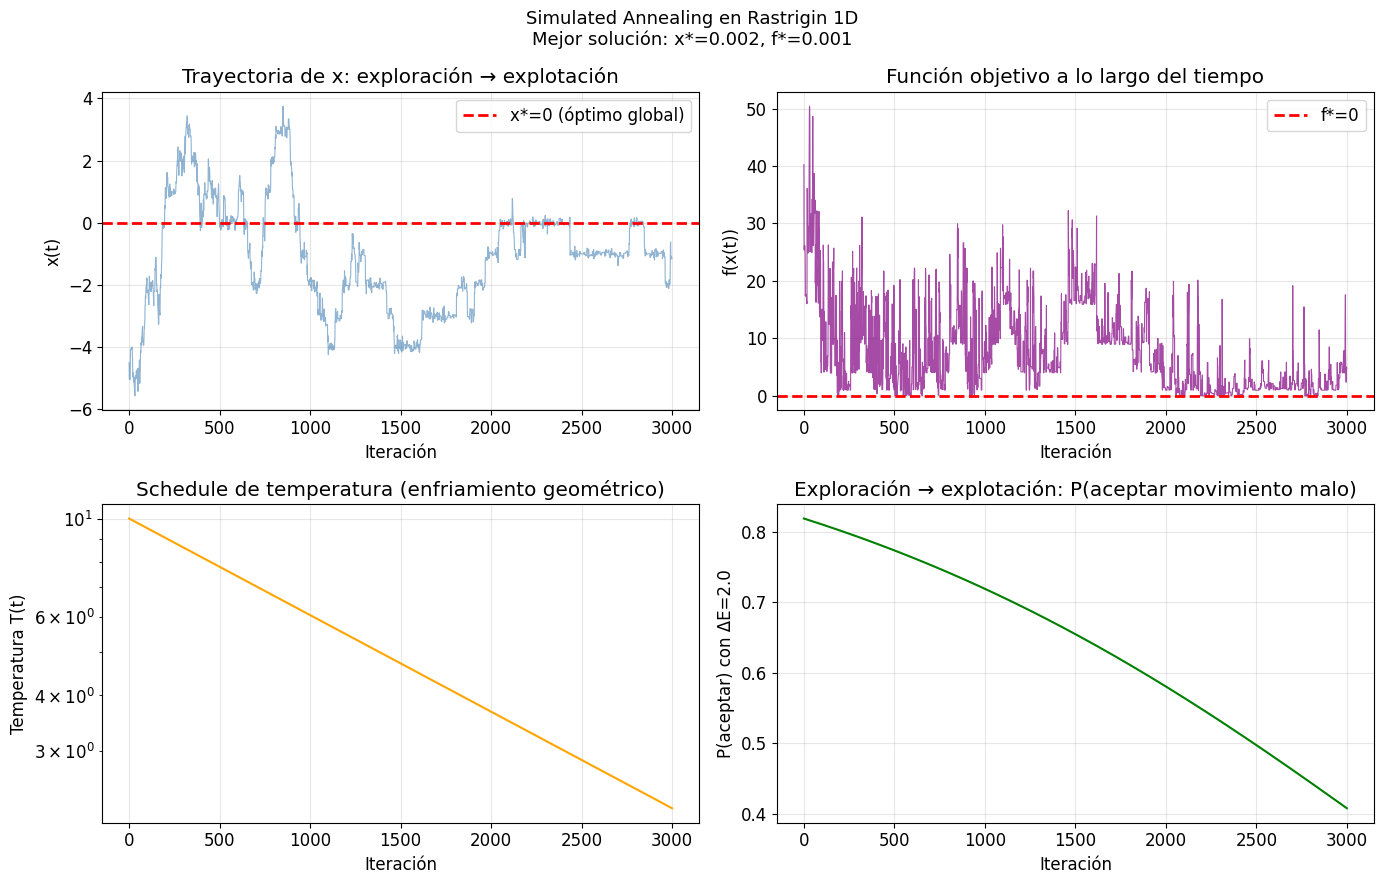

In [29]:
# Visualización de la trayectoria de SA
hist_x = np.array(hist_sa['x'])
hist_f = np.array(hist_sa['f'])
hist_T = np.array(hist_sa['T'])
iters = np.arange(len(hist_x))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Trayectoria x(t)
ax = axes[0, 0]
ax.plot(iters, hist_x, alpha=0.6, lw=0.8, color='steelblue')
ax.axhline(0, color='red', ls='--', lw=2, label='x*=0 (óptimo global)')
ax.set_xlabel('Iteración')
ax.set_ylabel('x(t)')
ax.set_title('Trayectoria de x: exploración → explotación')
ax.legend()
ax.grid(True, alpha=0.3)

# f(x(t))
ax = axes[0, 1]
ax.plot(iters, hist_f, alpha=0.7, lw=0.8, color='purple')
ax.axhline(0, color='red', ls='--', lw=2, label='f*=0')
ax.set_xlabel('Iteración')
ax.set_ylabel('f(x(t))')
ax.set_title('Función objetivo a lo largo del tiempo')
ax.legend()
ax.grid(True, alpha=0.3)

# Temperatura
ax = axes[1, 0]
ax.semilogy(iters, hist_T, color='orange', lw=1.5)
ax.set_xlabel('Iteración')
ax.set_ylabel('Temperatura T(t)')
ax.set_title('Schedule de temperatura (enfriamiento geométrico)')
ax.grid(True, alpha=0.3)

# Probabilidad de aceptación de movimientos malos
ax = axes[1, 1]
T_grid = np.array(hist_T)
delta_E_tipico = 2.0  # valor típico para Rastrigin
prob_aceptar = np.exp(-delta_E_tipico / np.maximum(T_grid, 1e-10))
ax.plot(iters, prob_aceptar, color='green', lw=1.5)
ax.set_xlabel('Iteración')
ax.set_ylabel(f'P(aceptar) con ΔE={delta_E_tipico}')
ax.set_title('Exploración → explotación: P(aceptar movimiento malo)')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Simulated Annealing en Rastrigin 1D\nMejor solución: x*={mejor_x:.3f}, f*={mejor_f:.3f}', 
             fontsize=13)
plt.tight_layout()
plt.show()

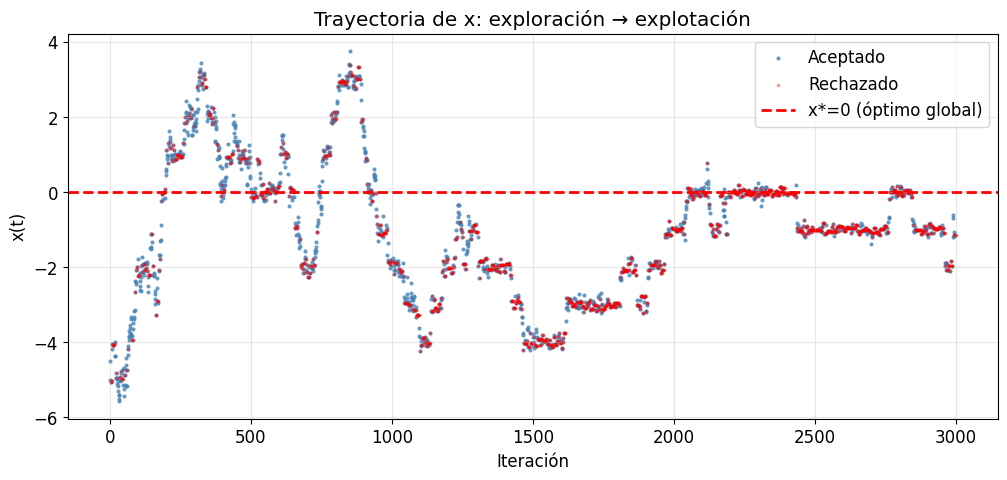

In [30]:
# Los puntos azules de la primer gráfica contienen tanto los aceptados como los no aceptados
# Grafiquemos la trayectoria de x(t) coloreada por aceptación/rechazo de movimientos
hist_aceptado = np.array(hist_sa['aceptado'])

# Trayectoria x(t) — coloreada por aceptación
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(iters[hist_aceptado], hist_x[hist_aceptado],
           color='steelblue', alpha=0.7, s=4, label='Aceptado')
ax.scatter(iters[~hist_aceptado], hist_x[~hist_aceptado],
           color='red', alpha=0.3, s=3, label='Rechazado')
ax.axhline(0, color='red', ls='--', lw=2, label='x*=0 (óptimo global)')
ax.set_xlabel('Iteración')
ax.set_ylabel('x(t)')
ax.set_title('Trayectoria de x: exploración → explotación')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 3. Comparación: SA vs Gradiente Descendente en Rastrigin

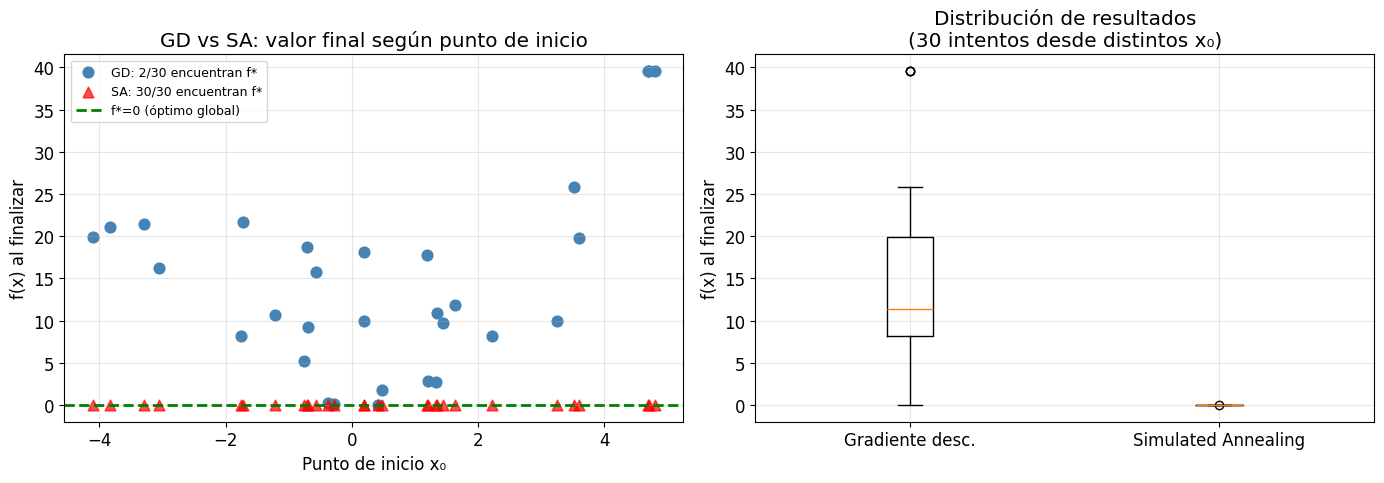

GD: media=14.554, éxitos (f<0.1): 2/30
SA: media=0.000, éxitos (f<0.1): 30/30


In [35]:
# Gradiente de Rastrigin (calculado analíticamente)
def d_rastrigin(x, A=10):
    return 2*x + 2*np.pi*A * np.sin(2*np.pi*x)

# Múltiples corridas de GD y SA desde distintos x0
n_intentos = 30
x0s = np.random.uniform(-5.12, 5.12, n_intentos)

resultados_gd = []
resultados_sa = []

for x0 in x0s:
    # Gradiente descendente
    x = x0
    for _ in range(500):
        x = x - 0.01 * d_rastrigin(x)
        x = np.clip(x, -5.12, 5.12)
    resultados_gd.append(rastrigin_1d(x))
    
    # SA
    _, f_sa, _ = simulated_annealing_1d(
        rastrigin_1d, x0, T0=10, alpha_cool=0.9995, 
        sigma_propuesta=0.5, max_iter=3000
    )
    resultados_sa.append(f_sa)

resultados_gd = np.array(resultados_gd)
resultados_sa = np.array(resultados_sa)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(x0s, resultados_gd, label=f'GD: {(resultados_gd < 0.1).sum()}/{n_intentos} encuentran f*', 
           color='steelblue', s=60)
ax.scatter(x0s, resultados_sa, label=f'SA: {(resultados_sa < 0.1).sum()}/{n_intentos} encuentran f*', 
           color='red', s=60, alpha=0.7, marker='^')
ax.axhline(0, color='green', ls='--', lw=2, label='f*=0 (óptimo global)')
ax.set_xlabel('Punto de inicio x₀')
ax.set_ylabel('f(x) al finalizar')
ax.set_title('GD vs SA: valor final según punto de inicio')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.boxplot([resultados_gd, resultados_sa], tick_labels=['Gradiente desc.', 'Simulated Annealing'])
ax.set_ylabel('f(x) al finalizar')
ax.set_title(f'Distribución de resultados\n({n_intentos} intentos desde distintos x₀)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GD: media={resultados_gd.mean():.3f}, éxitos (f<0.1): {(resultados_gd<0.1).sum()}/{n_intentos}")
print(f"SA: media={resultados_sa.mean():.3f}, éxitos (f<0.1): {(resultados_sa<0.1).sum()}/{n_intentos}")

## 4. Algoritmos Genéticos: optimización de función multimodal

In [6]:
class AlgoritmoGenetico:
    """
    AG para minimización de f(x) con x ∈ [x_min, x_max].
    Representación: vector real (no binario para simplificar).
    """
    def __init__(self, f, x_min, x_max, n_pop=50, p_cruce=0.8, p_mut=0.1, sigma_mut=0.3):
        self.f = f
        self.x_min = x_min
        self.x_max = x_max
        self.n_pop = n_pop
        self.p_cruce = p_cruce
        self.p_mut = p_mut
        self.sigma_mut = sigma_mut
        
        # Inicialización aleatoria
        self.poblacion = np.random.uniform(x_min, x_max, n_pop)
        self.fitness = np.array([f(x) for x in self.poblacion])
        self.historia_mejor = [self.fitness.min()]
        self.historia_media = [self.fitness.mean()]
    
    def seleccion_torneo(self, k=3):
        """Selección por torneo: elegir el mejor de k individuos aleatorios."""
        candidatos = np.random.choice(self.n_pop, k, replace=False)
        return candidatos[np.argmin(self.fitness[candidatos])]
    
    def cruce(self, padre1, padre2):
        """Cruce aritmético: hijo = alpha*p1 + (1-alpha)*p2."""
        if np.random.random() < self.p_cruce:
            alpha = np.random.random()
            return alpha * padre1 + (1 - alpha) * padre2
        return padre1.copy()
    
    def mutacion(self, individuo):
        """Mutación gaussiana."""
        if np.random.random() < self.p_mut:
            individuo += np.random.normal(0, self.sigma_mut)
            individuo = np.clip(individuo, self.x_min, self.x_max)
        return individuo
    
    def evolucionar(self):
        """Una generación."""
        nueva_poblacion = []
        
        # Elitismo: el mejor individuo pasa sin cambios
        idx_mejor = np.argmin(self.fitness)
        nueva_poblacion.append(self.poblacion[idx_mejor])
        
        # Generar n_pop - 1 hijos
        while len(nueva_poblacion) < self.n_pop:
            p1 = self.seleccion_torneo()
            p2 = self.seleccion_torneo()
            hijo = self.cruce(self.poblacion[p1], self.poblacion[p2])
            hijo = self.mutacion(hijo)
            nueva_poblacion.append(hijo)
        
        self.poblacion = np.array(nueva_poblacion)
        self.fitness = np.array([self.f(x) for x in self.poblacion])
        self.historia_mejor.append(self.fitness.min())
        self.historia_media.append(self.fitness.mean())
    
    def run(self, n_generaciones=100):
        for _ in range(n_generaciones):
            self.evolucionar()
        idx = np.argmin(self.fitness)
        return self.poblacion[idx], self.fitness[idx]

# Ejecutar AG en Rastrigin
ag = AlgoritmoGenetico(
    rastrigin_1d, x_min=-5.12, x_max=5.12,
    n_pop=80, p_cruce=0.85, p_mut=0.15, sigma_mut=0.4
)
mejor_ag_x, mejor_ag_f = ag.run(n_generaciones=100)

print(f"AG encontró: x* = {mejor_ag_x:.4f}, f* = {mejor_ag_f:.4f}")

AG encontró: x* = 0.0000, f* = 0.0000


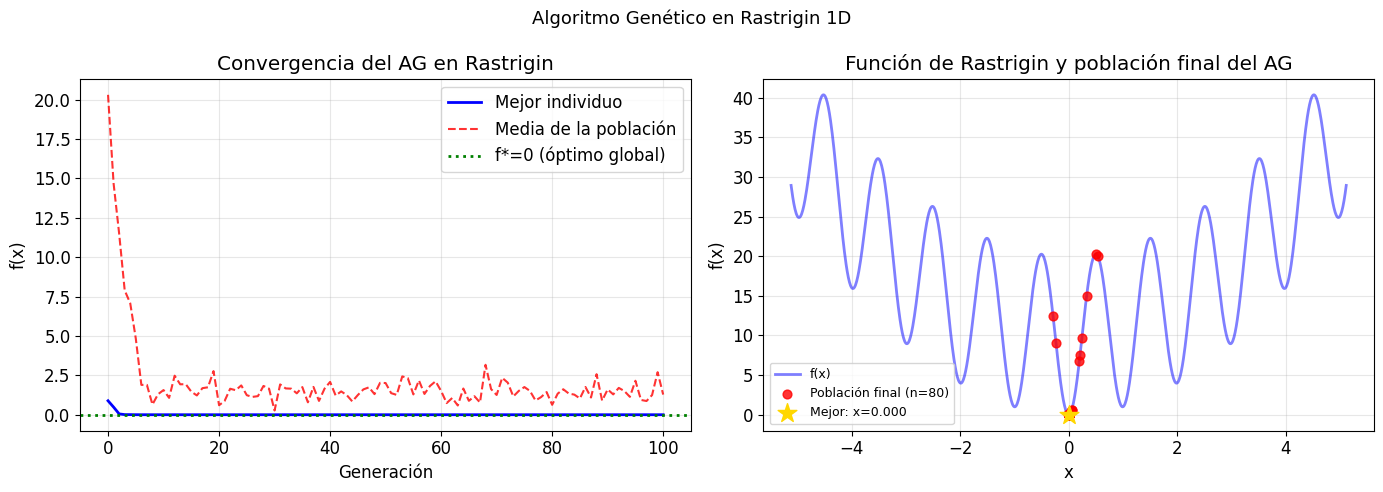

In [7]:
# Visualizar convergencia del AG
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
gens = range(len(ag.historia_mejor))
ax.plot(gens, ag.historia_mejor, 'b-', lw=2, label='Mejor individuo')
ax.plot(gens, ag.historia_media, 'r--', lw=1.5, alpha=0.8, label='Media de la población')
ax.axhline(0, color='green', ls=':', lw=2, label='f*=0 (óptimo global)')
ax.set_xlabel('Generación')
ax.set_ylabel('f(x)')
ax.set_title('Convergencia del AG en Rastrigin')
ax.legend()
ax.grid(True, alpha=0.3)

# Población final
ax = axes[1]
ax.plot(x_grid, rastrigin_1d(x_grid), 'b-', lw=2, alpha=0.5, label='f(x)')
ax.scatter(ag.poblacion, ag.fitness, color='red', s=40, alpha=0.8, 
           zorder=5, label=f'Población final (n={ag.n_pop})')
ax.scatter([mejor_ag_x], [mejor_ag_f], color='gold', s=200, marker='*', 
           zorder=6, label=f'Mejor: x={mejor_ag_x:.3f}')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Función de Rastrigin y población final del AG')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Algoritmo Genético en Rastrigin 1D', fontsize=13)
plt.tight_layout()
plt.show()

## 5. SA en el Problema del Viajante (TSP)

Un ejemplo de espacio discreto donde gradiente no funciona.

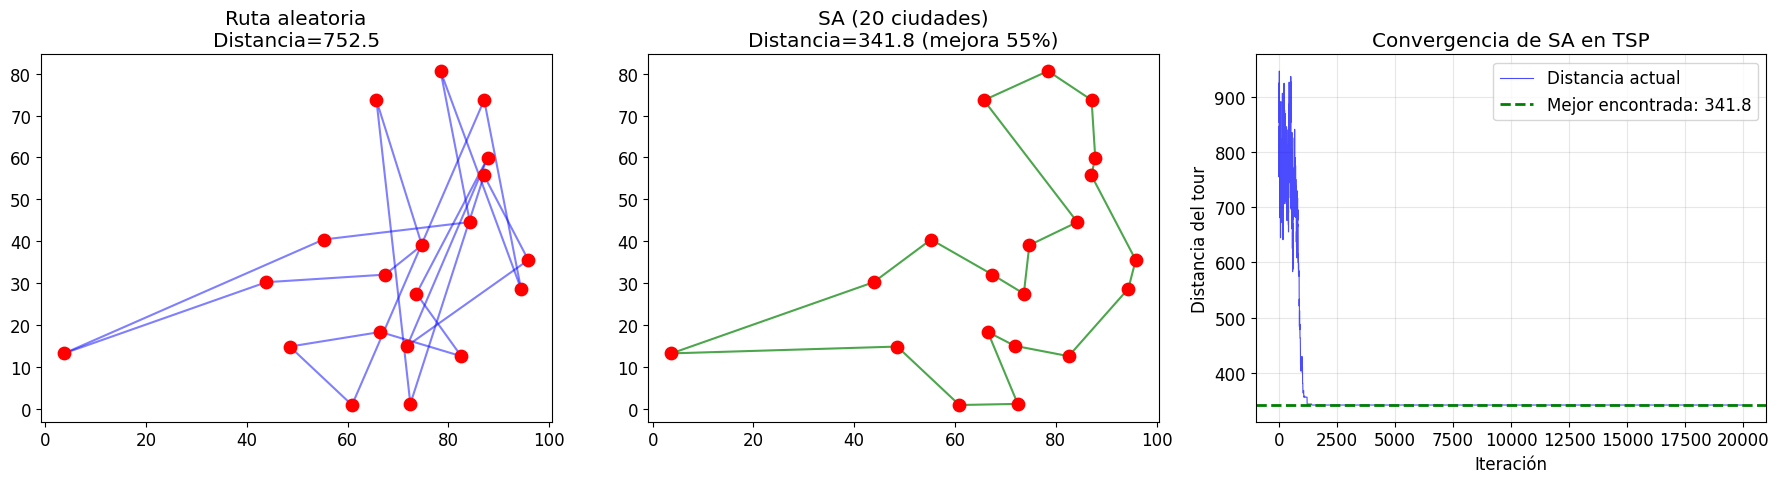

In [8]:
def distancia_ruta(ruta, ciudades):
    """Longitud total de un tour (ciclo)."""
    total = 0
    n = len(ruta)
    for i in range(n):
        total += np.linalg.norm(ciudades[ruta[i]] - ciudades[ruta[(i+1) % n]])
    return total

def vecino_tsp(ruta):
    """Intercambiar dos ciudades aleatoriamente (operador 2-opt simplificado)."""
    ruta = ruta.copy()
    i, j = np.sort(np.random.choice(len(ruta), 2, replace=False))
    ruta[i:j+1] = ruta[i:j+1][::-1]  # inversión del segmento
    return ruta

# Generar ciudades aleatorias
n_ciudades = 20
ciudades = np.random.rand(n_ciudades, 2) * 100
ruta_inicial = np.arange(n_ciudades)

# SA para TSP
def sa_tsp(ciudades, T0=1000, alpha_cool=0.995, max_iter=20000):
    n = len(ciudades)
    ruta = np.arange(n)
    np.random.shuffle(ruta)
    
    d_actual = distancia_ruta(ruta, ciudades)
    mejor_ruta = ruta.copy()
    mejor_d = d_actual
    T = T0
    historia_d = [d_actual]
    
    for _ in range(max_iter):
        ruta_nueva = vecino_tsp(ruta)
        d_nueva = distancia_ruta(ruta_nueva, ciudades)
        delta = d_nueva - d_actual
        
        if delta < 0 or np.random.random() < np.exp(-delta / T):
            ruta = ruta_nueva
            d_actual = d_nueva
            
            if d_actual < mejor_d:
                mejor_ruta = ruta.copy()
                mejor_d = d_actual
        
        T *= alpha_cool
        historia_d.append(d_actual)
    
    return mejor_ruta, mejor_d, historia_d

# Ejecutar SA
ruta_sa, dist_sa, hist_d = sa_tsp(ciudades)

# Ruta aleatoria como baseline
ruta_rand = np.arange(n_ciudades)
np.random.shuffle(ruta_rand)
dist_rand = distancia_ruta(ruta_rand, ciudades)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ruta aleatoria
ax = axes[0]
for i in range(n_ciudades):
    c1 = ciudades[ruta_rand[i]]
    c2 = ciudades[ruta_rand[(i+1)%n_ciudades]]
    ax.plot([c1[0], c2[0]], [c1[1], c2[1]], 'b-', alpha=0.5)
ax.scatter(ciudades[:,0], ciudades[:,1], color='red', s=80, zorder=5)
ax.set_title(f'Ruta aleatoria\nDistancia={dist_rand:.1f}')

# Ruta SA
ax = axes[1]
for i in range(n_ciudades):
    c1 = ciudades[ruta_sa[i]]
    c2 = ciudades[ruta_sa[(i+1)%n_ciudades]]
    ax.plot([c1[0], c2[0]], [c1[1], c2[1]], 'g-', alpha=0.7, lw=1.5)
ax.scatter(ciudades[:,0], ciudades[:,1], color='red', s=80, zorder=5)
ax.set_title(f'SA ({n_ciudades} ciudades)\nDistancia={dist_sa:.1f} (mejora {(1-dist_sa/dist_rand)*100:.0f}%)')

# Convergencia
ax = axes[2]
ax.plot(hist_d, 'b-', lw=0.8, alpha=0.7, label='Distancia actual')
ax.axhline(dist_sa, color='green', ls='--', lw=2, label=f'Mejor encontrada: {dist_sa:.1f}')
ax.set_xlabel('Iteración')
ax.set_ylabel('Distancia del tour')
ax.set_title('Convergencia de SA en TSP')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Resumen

- **Metaheurísticas**: para problemas donde el gradiente no es aplicable (discreto, multimodal, no diferenciable).
- **SA**: un agente que acepta movimientos malos con P = exp(-ΔE/T). Alta T → exploración; baja T → explotación.
- **AG**: población que evoluciona por selección, cruce y mutación. Naturalmente paralelo.
- **Tradeoff**: exploración (escapar mínimos locales) vs. explotación (refinar buenas soluciones).
- **Sin garantías de óptimo global** en tiempo finito — pero en la práctica son muy efectivos.